In [ ]:
!pip install lifelines lifetimes pandas numpy matplotlib seaborn \
            plotly scikit-learn scipy streamlit -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import pickle
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("✅ All imports successful")

✅ All imports successful


In [ ]:
def load_and_clean_data(filepath='online_retail_II.csv'):
    """
    Load and clean the Online Retail II dataset
    Handles: nulls, cancellations, negative quantities, duplicates
    """
    print("📂 Loading dataset...")

    # Load — try CSV first, then Excel
    try:
        df = pd.read_csv(filepath)
    except:
        try:
            # Excel has 2 sheets — Year 2009-2010 and 2010-2011
            df1 = pd.read_excel(filepath, sheet_name='Year 2009-2010')
            df2 = pd.read_excel(filepath, sheet_name='Year 2010-2011')
            df  = pd.concat([df1, df2], ignore_index=True)
        except:
            print("❌ File not found — generating synthetic data instead")
            return generate_synthetic_retail_data()

    print(f"   Raw shape: {df.shape}")

    # Standardise column names
    df.columns = df.columns.str.strip().str.replace(' ', '')

    # Rename to standard names if needed
    rename_map = {
        'Customer ID' : 'CustomerID',
        'Invoice'     : 'InvoiceNo',
        'StockCode'   : 'StockCode',
        'Description' : 'Description',
        'Quantity'    : 'Quantity',
        'InvoiceDate' : 'InvoiceDate',
        'Price'       : 'UnitPrice',
        'Country'     : 'Country',
    }
    for old, new in rename_map.items():
        if old in df.columns:
            df = df.rename(columns={old: new})

    # Drop nulls in critical columns
    df = df.dropna(subset=['CustomerID', 'InvoiceDate'])

    # Convert types
    df['CustomerID']  = df['CustomerID'].astype(int).astype(str)
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    # Remove cancellations (InvoiceNo starts with C)
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

    # Remove negative quantities and prices
    df = df[df['Quantity']  > 0]
    df = df[df['UnitPrice'] > 0]

    # Remove test/sample entries
    df = df[df['CustomerID'].str.isdigit()]

    # Add TotalAmount
    df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

    # Remove outliers — top 1% spenders (likely B2B)
    upper = df.groupby('CustomerID')['TotalAmount'].sum().quantile(0.99)
    valid_customers = df.groupby('CustomerID')['TotalAmount'].sum()
    valid_customers = valid_customers[valid_customers <= upper].index
    df = df[df['CustomerID'].isin(valid_customers)]

    # Remove duplicates
    df = df.drop_duplicates()

    print(f"   Clean shape : {df.shape}")
    print(f"   Customers   : {df['CustomerID'].nunique():,}")
    print(f"   Date range  : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
    print(f"   Total revenue: £{df['TotalAmount'].sum():,.0f}")

    return df


def generate_synthetic_retail_data(n_customers=2000, n_transactions=50000):
    """
    Fallback — generate synthetic e-commerce data
    if real dataset not available
    """
    print("🔧 Generating synthetic retail data...")
    np.random.seed(42)

    customers = [f'CUST{str(i+1).zfill(5)}' for i in range(n_customers)]

    # Customer archetypes
    archetypes = np.random.choice(
        ['champion', 'loyal', 'at_risk', 'lost'],
        size=n_customers,
        p=[0.15, 0.30, 0.30, 0.25]
    )

    archetype_map = {
        'champion' : {'freq': (8, 24),  'spend': (50, 500),  'recency': (1, 30)},
        'loyal'    : {'freq': (4, 12),  'spend': (30, 200),  'recency': (15, 60)},
        'at_risk'  : {'freq': (2, 6),   'spend': (20, 100),  'recency': (60, 180)},
        'lost'     : {'freq': (1, 3),   'spend': (10, 50),   'recency': (180, 365)},
    }

    records = []
    start_date = datetime(2022, 1, 1)
    end_date   = datetime(2024, 1, 1)

    for cust_id, archetype in zip(customers, archetypes):
        arch    = archetype_map[archetype]
        n_trans = np.random.randint(*arch['freq'])

        # Last purchase recency
        last_purchase_days = np.random.randint(*arch['recency'])
        last_date = end_date - timedelta(days=last_purchase_days)

        # Spread transactions over time
        for _ in range(n_trans):
            days_back = np.random.randint(last_purchase_days, 730)
            inv_date  = end_date - timedelta(days=days_back)
            if inv_date < start_date:
                continue
            spend = np.random.uniform(*arch['spend'])
            records.append({
                'CustomerID'  : cust_id,
                'InvoiceNo'   : f'INV{np.random.randint(100000, 999999)}',
                'InvoiceDate' : inv_date,
                'TotalAmount' : round(spend, 2),
                'Country'     : np.random.choice(
                    ['United Kingdom', 'Germany', 'France', 'Australia'],
                    p=[0.85, 0.06, 0.05, 0.04]
                ),
            })

    df = pd.DataFrame(records)
    df = df.sort_values('InvoiceDate').reset_index(drop=True)

    print(f"✅ Synthetic data generated: {df.shape}")
    print(f"   Customers: {df['CustomerID'].nunique():,}")
    return df


# Load data
df = load_and_clean_data('online_retail_II.csv')
df.to_csv('retail_clean.csv', index=False)
print("\n✅ Clean data saved to retail_clean.csv")
print(df.head())


📂 Loading dataset...
   Raw shape: (141520, 8)
   Clean shape : (93912, 9)
   Customers   : 2,074
   Date range  : 2009-12-01 → 2010-03-28
   Total revenue: £1,668,883

✅ Clean data saved to retail_clean.csv
  InvoiceNo StockCode                          Description  Quantity  \
0    489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1    489434    79323P                   PINK CHERRY LIGHTS        12   
2    489434    79323W                  WHITE CHERRY LIGHTS        12   
3    489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4    489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  UnitPrice CustomerID         Country  TotalAmount  
0 2009-12-01 07:45:00       6.95      13085  United Kingdom         83.4  
1 2009-12-01 07:45:00       6.75      13085  United Kingdom         81.0  
2 2009-12-01 07:45:00       6.75      13085  United Kingdom         81.0  
3 2009-12-01 07:45:00       2.10      13085  United Kingdom

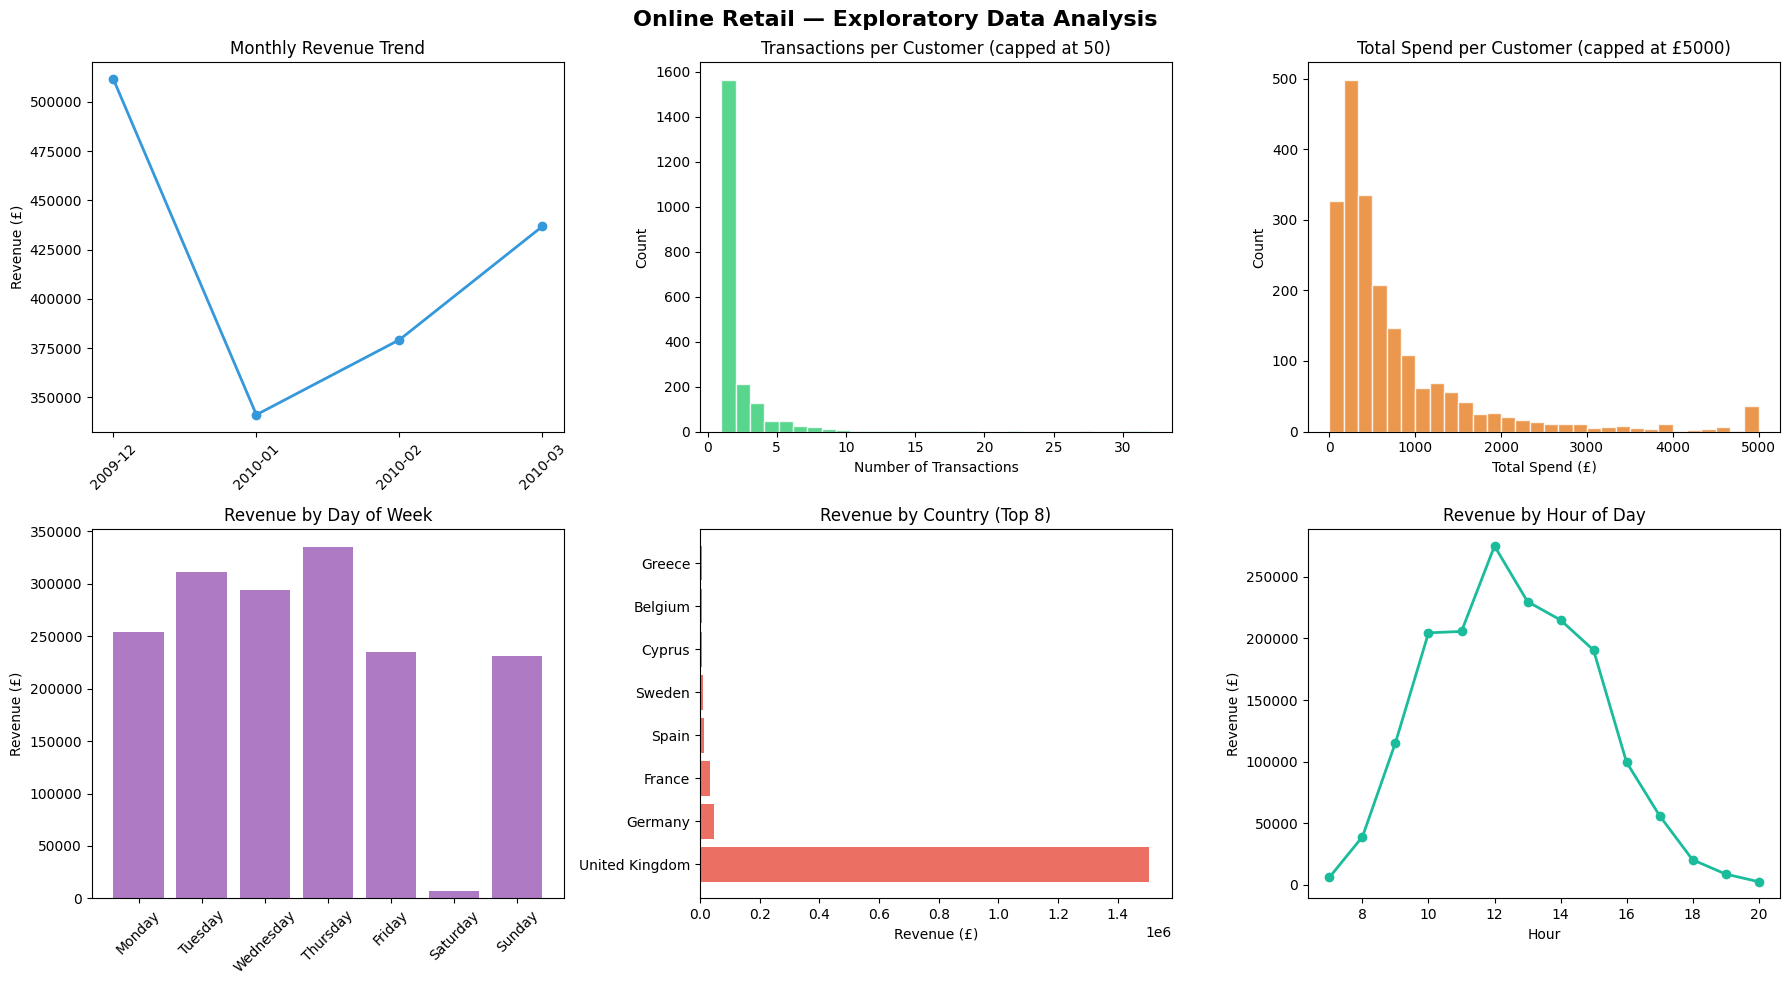

✅ EDA chart saved


In [ ]:
# Cell 2.1 — Revenue & transaction EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Online Retail — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Monthly revenue trend
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_rev = df.groupby('YearMonth')['TotalAmount'].sum()
axes[0,0].plot(monthly_rev.index.astype(str), monthly_rev.values,
               marker='o', linewidth=2, color='#3498DB')
axes[0,0].set_title('Monthly Revenue Trend')
axes[0,0].set_ylabel('Revenue (£)')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Transactions per customer distribution
trans_per_cust = df.groupby('CustomerID')['InvoiceNo'].nunique()
axes[0,1].hist(trans_per_cust.clip(upper=50), bins=30,
               color='#2ECC71', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Transactions per Customer (capped at 50)')
axes[0,1].set_xlabel('Number of Transactions')
axes[0,1].set_ylabel('Count')

# 3. Spend distribution per customer
total_spend = df.groupby('CustomerID')['TotalAmount'].sum()
axes[0,2].hist(total_spend.clip(upper=5000), bins=30,
               color='#E67E22', alpha=0.8, edgecolor='white')
axes[0,2].set_title('Total Spend per Customer (capped at £5000)')
axes[0,2].set_xlabel('Total Spend (£)')
axes[0,2].set_ylabel('Count')

# 4. Day of week analysis
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df.groupby('DayOfWeek')['TotalAmount'].sum().reindex(day_order)
axes[1,0].bar(day_order, dow_counts.values, color='#9B59B6', alpha=0.8)
axes[1,0].set_title('Revenue by Day of Week')
axes[1,0].set_ylabel('Revenue (£)')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Top countries
top_countries = df.groupby('Country')['TotalAmount'].sum().nlargest(8)
axes[1,1].barh(top_countries.index, top_countries.values,
               color='#E74C3C', alpha=0.8)
axes[1,1].set_title('Revenue by Country (Top 8)')
axes[1,1].set_xlabel('Revenue (£)')

# 6. Hour of day analysis
if df['InvoiceDate'].dt.hour.nunique() > 1:
    hour_rev = df.groupby(df['InvoiceDate'].dt.hour)['TotalAmount'].sum()
    axes[1,2].plot(hour_rev.index, hour_rev.values,
                   marker='o', color='#1ABC9C', linewidth=2)
    axes[1,2].set_title('Revenue by Hour of Day')
    axes[1,2].set_xlabel('Hour')
    axes[1,2].set_ylabel('Revenue (£)')
else:
    df['Month'] = df['InvoiceDate'].dt.month
    month_avg = df.groupby('Month')['TotalAmount'].mean()
    axes[1,2].bar(month_avg.index, month_avg.values, color='#1ABC9C', alpha=0.8)
    axes[1,2].set_title('Avg Transaction Value by Month')
    axes[1,2].set_xlabel('Month')

plt.tight_layout()
plt.savefig('eda_retail.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA chart saved")

✅ RFM calculated for 2,074 customers
       recency  frequency  monetary
count  2074.00    2074.00   2074.00
mean     44.21       2.17    804.67
std      35.95       2.30   1127.03
min       1.00       1.00      1.30
25%      14.00       1.00    232.87
50%      33.00       1.00    422.70
75%      64.00       2.00    887.50
max     118.00      32.00   9530.08

✅ RFM scores calculated
       r_score  f_score  m_score  rfm_score
count  2074.00  2074.00  2074.00    2074.00
mean      3.03     3.00     3.00       9.03
std       1.43     1.41     1.41       3.35
min       1.00     1.00     1.00       3.00
25%       2.00     2.00     2.00       6.00
50%       3.00     3.00     3.00       9.00
75%       4.00     4.00     4.00      12.00
max       5.00     5.00     5.00      15.00


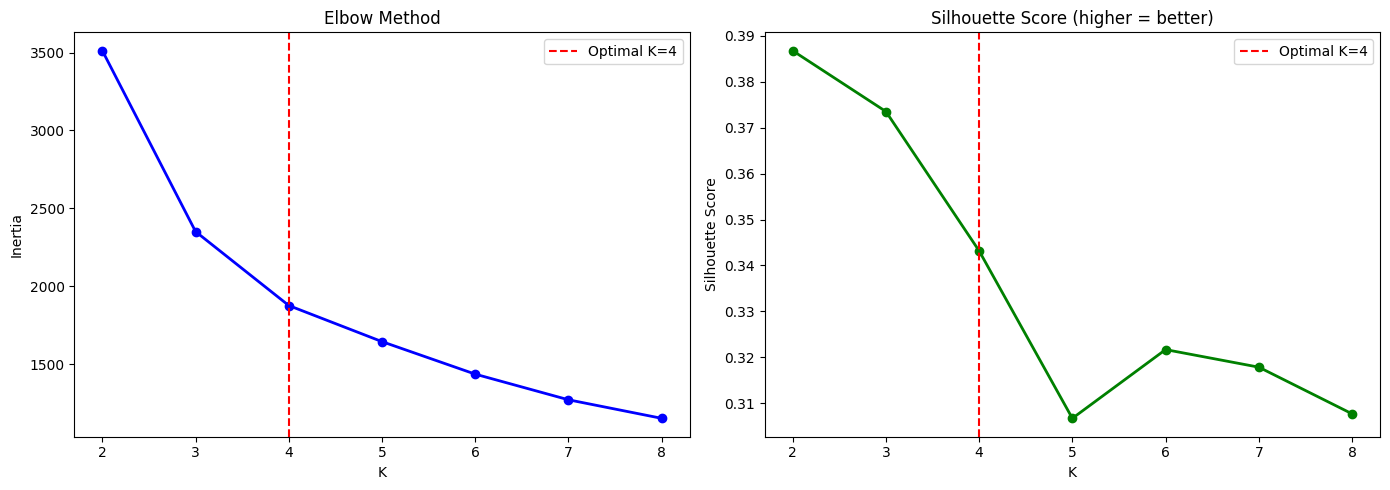

✅ Best silhouette score: 0.387 at K=4

Cluster profiles:
         recency  frequency  monetary
cluster                              
0          100.2        1.2     333.0
1           26.7        2.3     944.1
2           32.4        1.1     283.8
3           16.7        6.3    2676.5

✅ Customer Segments:
           count  avg_recency  avg_freq  avg_spend  total_spend
segment                                                        
Champions    275         17.0       6.0     2676.0     736037.0
Lost         476        100.0       1.0      333.0     158508.0
Loyal       1323         30.0       2.0      585.0     774339.0
✅ RFM data and models saved

📊 Statistical Test — Champions vs Lost Spending:
   Champions avg : £2676.50
   Lost avg      : £333.00
   t-statistic   : 25.611
   p-value       : 0.000000
   Cohen's d     : 1.673
   Significant?  : ✅ Yes (p < 0.05)

💡 Pareto Insight: Top 20% of customers contribute 60.1% of total revenue


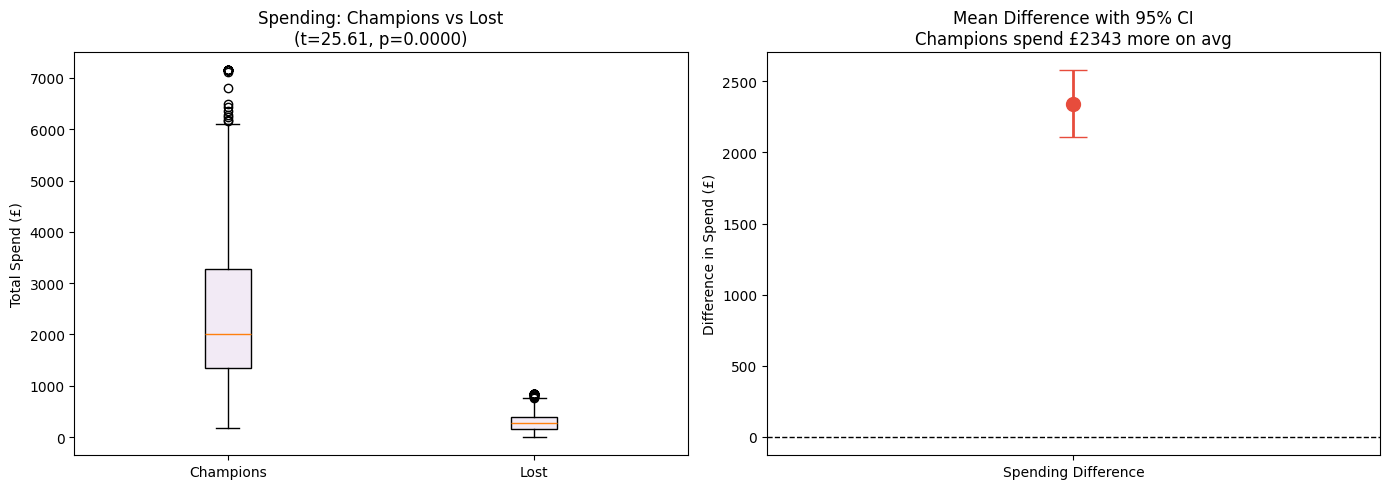

✅ t-test confidence interval plot saved


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy import stats

# Cell 3.1 — Calculate RFM
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    recency   = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    frequency = ('InvoiceNo',    'nunique'),
    monetary  = ('TotalAmount',  'sum'),
).reset_index()

# Log transform monetary to reduce skew
rfm['monetary_log'] = np.log1p(rfm['monetary'])
rfm['frequency_log'] = np.log1p(rfm['frequency'])

print(f"✅ RFM calculated for {len(rfm):,} customers")
print(rfm[['recency','frequency','monetary']].describe().round(2))


# Cell 3.2 — Score RFM 1-5
def score_rfm(df):
    df = df.copy()
    # Recency: lower = better → reverse score
    df['r_score'] = pd.qcut(df['recency'],   5, labels=[5,4,3,2,1], duplicates='drop')
    df['f_score'] = pd.qcut(df['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
    df['m_score'] = pd.qcut(df['monetary'],  5, labels=[1,2,3,4,5], duplicates='drop')

    df['r_score'] = df['r_score'].astype(int)
    df['f_score'] = df['f_score'].astype(int)
    df['m_score'] = df['m_score'].astype(int)
    df['rfm_score'] = df['r_score'] + df['f_score'] + df['m_score']
    return df

rfm = score_rfm(rfm)
print("\n✅ RFM scores calculated")
print(rfm[['r_score','f_score','m_score','rfm_score']].describe().round(2))


# Cell 3.3 — K-Means clustering
scaler = StandardScaler()
X_rfm  = scaler.fit_transform(rfm[['recency','frequency_log','monetary_log']])

# Find optimal K using elbow + silhouette
inertias    = []
silhouettes = []
K_range     = range(2, 9)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_rfm)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_rfm, lbl))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, 'bo-', linewidth=2)
ax1.axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
ax1.set_title('Elbow Method')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')
ax1.legend()

ax2.plot(K_range, silhouettes, 'go-', linewidth=2)
ax2.axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
ax2.set_title('Silhouette Score (higher = better)')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')
ax2.legend()

plt.tight_layout()
plt.savefig('kmeans_selection.png', dpi=150)
plt.show()
print(f"✅ Best silhouette score: {max(silhouettes):.3f} at K=4")


# Cell 3.4 — Final segmentation
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(X_rfm)

# Auto-label clusters based on RFM profile
cluster_profile = rfm.groupby('cluster')[['recency','frequency','monetary']].mean()
print("\nCluster profiles:")
print(cluster_profile.round(1))

# Label by characteristics
labels = {}
for c in range(4):
    r = cluster_profile.loc[c, 'recency']
    f = cluster_profile.loc[c, 'frequency']
    m = cluster_profile.loc[c, 'monetary']

    if f == cluster_profile['frequency'].max():
        labels[c] = 'Champions'
    elif r == cluster_profile['recency'].min():
        labels[c] = 'Recent'
    elif r == cluster_profile['recency'].max():
        labels[c] = 'Lost'
    else:
        labels[c] = 'Loyal'

rfm['segment'] = rfm['cluster'].map(labels)

# Segment summary
seg_summary = rfm.groupby('segment').agg(
    count       = ('CustomerID', 'count'),
    avg_recency = ('recency',    'mean'),
    avg_freq    = ('frequency',  'mean'),
    avg_spend   = ('monetary',   'mean'),
    total_spend = ('monetary',   'sum'),
).round(0)

print("\n✅ Customer Segments:")
print(seg_summary)

# Save RFM
rfm.to_csv('rfm_segments.csv', index=False)
with open('rfm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('rfm_kmeans.pkl', 'wb') as f:
    pickle.dump(km_final, f)
print("✅ RFM data and models saved")


# Cell 3.5 — Statistical validation
# t-test: Champions vs Lost — is spending difference significant?
champions = rfm[rfm['segment'] == 'Champions']['monetary']
lost      = rfm[rfm['segment'] == 'Lost']['monetary']
loyal     = rfm[rfm['segment'] == 'Loyal']['monetary']

t_stat, p_value = stats.ttest_ind(champions, lost)
cohens_d = (champions.mean() - lost.mean()) / np.sqrt(
    (champions.std()**2 + lost.std()**2) / 2
)

print(f"\n📊 Statistical Test — Champions vs Lost Spending:")
print(f"   Champions avg : £{champions.mean():.2f}")
print(f"   Lost avg      : £{lost.mean():.2f}")
print(f"   t-statistic   : {t_stat:.3f}")
print(f"   p-value       : {p_value:.6f}")
print(f"   Cohen's d     : {cohens_d:.3f}")
print(f"   Significant?  : {'✅ Yes (p < 0.05)' if p_value < 0.05 else '❌ No'}")

# Pareto analysis
rfm_sorted    = rfm.sort_values('monetary', ascending=False)
top20_revenue = rfm_sorted.head(int(len(rfm)*0.20))['monetary'].sum()
total_revenue = rfm['monetary'].sum()
pareto_pct    = top20_revenue / total_revenue * 100

print(f"\n💡 Pareto Insight: Top 20% of customers contribute {pareto_pct:.1f}% of total revenue")

# Confidence interval plot for Champions vs Lost
from scipy import stats as scipy_stats

n1, n2    = len(champions), len(lost)
se_diff   = np.sqrt(champions.var()/n1 + lost.var()/n2)
mean_diff = champions.mean() - lost.mean()
ci_low    = mean_diff - 1.96 * se_diff
ci_high   = mean_diff + 1.96 * se_diff

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot comparison
axes[0].boxplot(
    [champions.clip(upper=champions.quantile(0.95)),
     lost.clip(upper=lost.quantile(0.95))],
    labels=['Champions','Lost'],
    patch_artist=True,
    boxprops=dict(facecolor='#9B59B620'),
)
axes[0].set_title(f'Spending: Champions vs Lost\n(t={t_stat:.2f}, p={p_value:.4f})')
axes[0].set_ylabel('Total Spend (£)')

# Confidence interval plot
axes[1].errorbar(
    ['Spending Difference'],
    [mean_diff],
    yerr=[[(mean_diff - ci_low)], [(ci_high - mean_diff)]],
    fmt='o', color='#E74C3C', markersize=10, capsize=10, linewidth=2
)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title(f'Mean Difference with 95% CI\nChampions spend £{mean_diff:.0f} more on avg')
axes[1].set_ylabel('Difference in Spend (£)')

plt.tight_layout()
plt.savefig('ttest_confidence_interval.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-test confidence interval plot saved")

# Visualise segments
fig = px.scatter(
    rfm, x='recency', y='frequency',
    size='monetary', color='segment',
    title='Customer Segments — RFM Scatter (bubble size = spend)',
    labels={
        'recency'  : 'Recency (days since last purchase)',
        'frequency': 'Purchase Frequency',
    },
    color_discrete_map={
        'Champions': '#9B59B6',
        'Loyal'    : '#3498DB',
        'Recent'   : '#2ECC71',
        'Lost'     : '#E74C3C',
    }
)
fig.write_html('rfm_scatter.html')
fig.show()


✅ Survival data prepared: 2,074 customers
   Overall churn rate : 17.4%
   Avg lifetime       : 30 days

Churn by segment:
segment
Champions    0.004
Lost         0.750
Loyal        0.002
Name: churned, dtype: float64


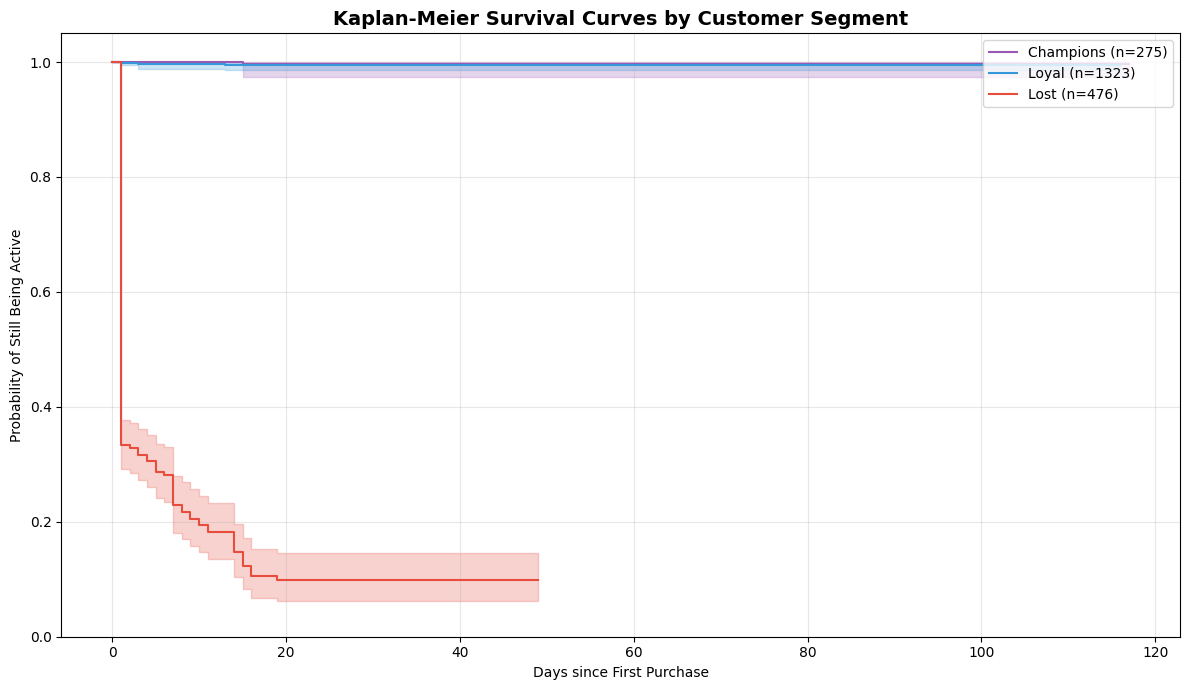

✅ Kaplan-Meier curves saved

📊 Log-rank Test: Champions vs Lost Survival
   Test statistic  : 485.817
   p-value         : 0.000000
   Significant?    : ✅ Yes — survival curves are significantly different

   Champions median survival : inf days
   Lost median survival      : 1 days

📊 Cox Proportional Hazards Model — Hazard Ratios:


<lifelines.CoxPHFitter: fitted with 2074 total observations, 1713 right-censored observations>
             duration col = 'lifetime_days'
                event col = 'churned'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 2074
number of events observed = 361
   partial log-likelihood = -2147.669
         time fit was run = 2026-05-05 00:23:31 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
frequency -0.166     0.847     0.065          -0.293          -0.039               0.746               0.961
monetary  -0.073     0.929     0.061          -0.192           0.046               0.825               1.047
recency    1.207     3.342     0.049           1.111           1.302               3.038               3.676
rfm_score -0.485     0.616     0.056          -0.595          -0.374               0.551               0.688

           cmp to      z       p  -log2(p)
covariate                                 
frequency   0.000 -2.568   0.010     6.613
monetary    0.000 -1.205   0.228     2.130
recency     0.000 24.800 <0.0005   448.619
rfm_score   0.000 -8.582 <0.0005    56.572
---
Concordance = 0.998
Partial AIC = 4303.338
log-likelihood ratio test = 1090.839 on 4 df
-log2(p) of ll-ratio test = 777.780

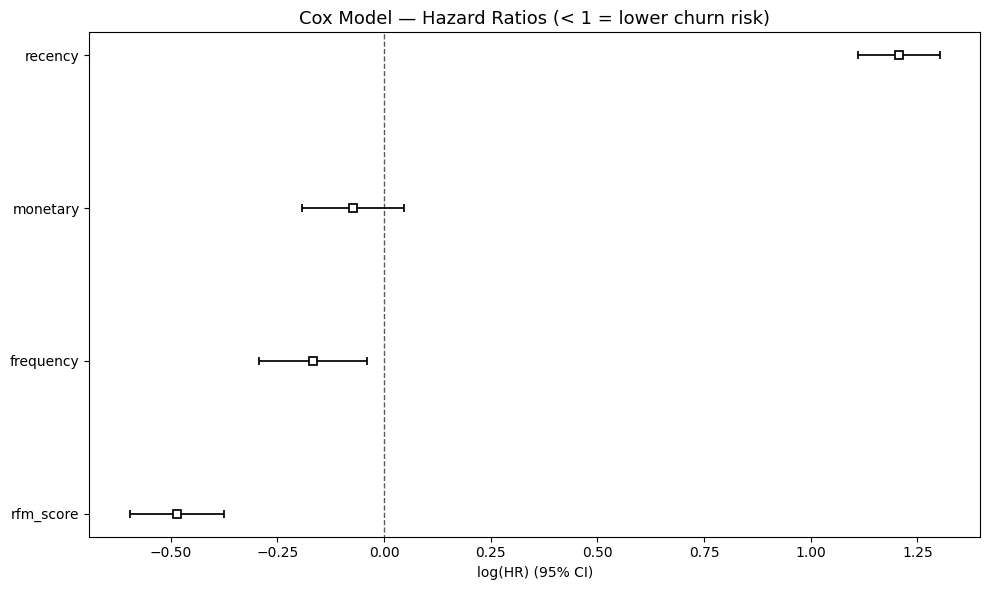

✅ Cox model and survival data saved


In [ ]:
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# Cell 4.1 — Prepare survival data
def prepare_survival_data(df, rfm):
    """
    Create survival dataset:
    duration  = customer lifetime in days (first to last purchase)
    event     = 1 if churned (no purchase in last 90 days), 0 if still active
    """
    snapshot = df['InvoiceDate'].max()

    survival = df.groupby('CustomerID').agg(
        first_purchase = ('InvoiceDate', 'min'),
        last_purchase  = ('InvoiceDate', 'max'),
    ).reset_index()

    survival['lifetime_days'] = (
        survival['last_purchase'] - survival['first_purchase']
    ).dt.days + 1

    # Churn definition: no purchase in last 90 days = churned
    survival['churned'] = (
        (snapshot - survival['last_purchase']).dt.days > 90
    ).astype(int)

    # Minimum 1 day lifetime
    survival['lifetime_days'] = survival['lifetime_days'].clip(lower=1)

    # Merge with RFM segments
    survival = survival.merge(
        rfm[['CustomerID', 'segment', 'recency', 'frequency',
              'monetary', 'rfm_score']],
        on='CustomerID', how='inner'
    )

    return survival

survival_df = prepare_survival_data(df, rfm)

print(f"✅ Survival data prepared: {len(survival_df):,} customers")
print(f"   Overall churn rate : {survival_df['churned'].mean():.1%}")
print(f"   Avg lifetime       : {survival_df['lifetime_days'].mean():.0f} days")
print(f"\nChurn by segment:")
print(survival_df.groupby('segment')['churned'].mean().round(3))


# Cell 4.2 — Kaplan-Meier curves per segment
fig, ax = plt.subplots(figsize=(12, 7))

colors   = {'Champions':'#9B59B6','Loyal':'#3498DB','Recent':'#2ECC71','Lost':'#E74C3C'}
kmf_dict = {}

for segment in ['Champions', 'Loyal', 'Recent', 'Lost']:
    seg_data = survival_df[survival_df['segment'] == segment]
    if len(seg_data) < 10:
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(
        durations       = seg_data['lifetime_days'],
        event_observed  = seg_data['churned'],
        label           = f"{segment} (n={len(seg_data)})"
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[segment])
    kmf_dict[segment] = kmf

ax.set_title('Kaplan-Meier Survival Curves by Customer Segment',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Days since First Purchase')
ax.set_ylabel('Probability of Still Being Active')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('km_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Kaplan-Meier curves saved")


# Cell 4.3 — Log-rank test: Champions vs Lost
champ_data = survival_df[survival_df['segment'] == 'Champions']
lost_data  = survival_df[survival_df['segment'] == 'Lost']

if len(champ_data) > 5 and len(lost_data) > 5:
    logrank_result = logrank_test(
        durations_A         = champ_data['lifetime_days'],
        durations_B         = lost_data['lifetime_days'],
        event_observed_A    = champ_data['churned'],
        event_observed_B    = lost_data['churned'],
    )

    print(f"\n📊 Log-rank Test: Champions vs Lost Survival")
    print(f"   Test statistic  : {logrank_result.test_statistic:.3f}")
    print(f"   p-value         : {logrank_result.p_value:.6f}")
    print(f"   Significant?    : {'✅ Yes — survival curves are significantly different' if logrank_result.p_value < 0.05 else '❌ No'}")
    print(f"\n   Champions median survival : {kmf_dict.get('Champions', KaplanMeierFitter()).median_survival_time_:.0f} days")
    print(f"   Lost median survival      : {kmf_dict.get('Lost', KaplanMeierFitter()).median_survival_time_:.0f} days")


# Cell 4.4 — Cox Proportional Hazards model
# Prepare features for Cox model
cox_df = survival_df[['lifetime_days','churned',
                        'frequency','monetary','recency','rfm_score']].copy()

# Normalise for Cox model
for col in ['frequency','monetary','recency','rfm_score']:
    cox_df[col] = (cox_df[col] - cox_df[col].mean()) / cox_df[col].std()

cox_df = cox_df.dropna()

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col='lifetime_days', event_col='churned')

print("\n📊 Cox Proportional Hazards Model — Hazard Ratios:")
cph.print_summary(decimals=3)

# Visualise hazard ratios
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Cox Model — Hazard Ratios (< 1 = lower churn risk)', fontsize=13)
plt.tight_layout()
plt.savefig('cox_hazard_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

# Save survival models
with open('cox_model.pkl', 'wb') as f:
    pickle.dump(cph, f)
survival_df.to_csv('survival_data.csv', index=False)
print("✅ Cox model and survival data saved")


✅ Data prepared
Total customers: 2074
Repeat customers: 901
✅ Train/Test ready
Split date: 2010-03-07 14:39:00
✅ BG/NBD trained

📊 Evaluation Results
MAE : 0.3936020855210375
RMSE: 0.6306284190212577
Corr: 0.48840042110658893


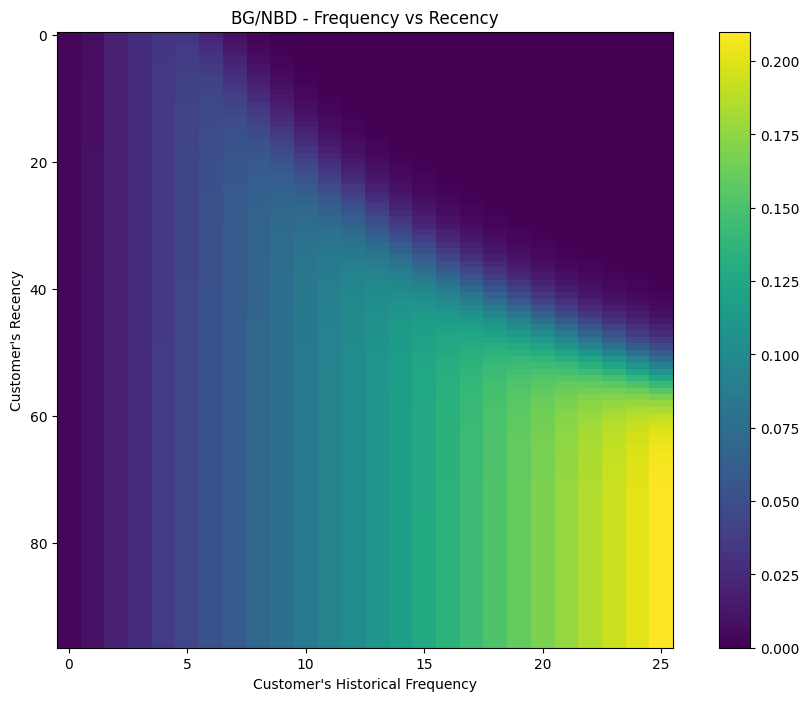

✅ Gamma-Gamma trained

📊 CLV Summary
Avg CLV: 6575.645667695107
Avg Alive: 0.8731889465411752
✅ Models saved safely (JSON format)


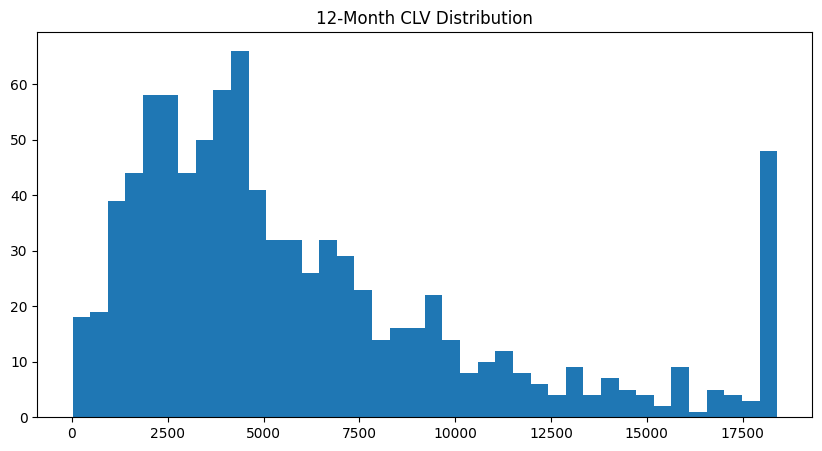

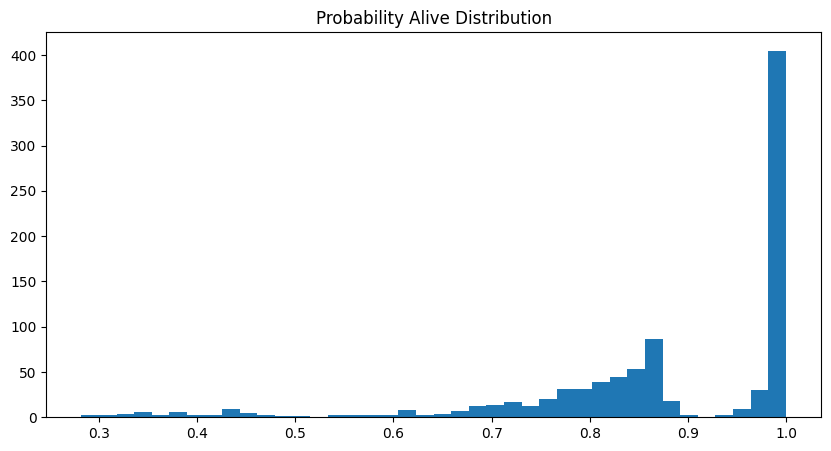

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import plot_frequency_recency_matrix


# =========================
# 1. Prepare Data
# =========================
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

snapshot = df['InvoiceDate'].max()

summary = summary_data_from_transaction_data(
    df,
    customer_id_col='CustomerID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalAmount',
    observation_period_end=snapshot
)

summary_gg = summary[summary['frequency'] > 0].copy()

print("✅ Data prepared")
print("Total customers:", len(summary))
print("Repeat customers:", len(summary_gg))


# =========================
# 2. Train/Test Split (SAFE)
# =========================
split_date = df['InvoiceDate'].quantile(0.8)

train_df = df[df['InvoiceDate'] < split_date]
test_df  = df[df['InvoiceDate'] >= split_date]

train_summary = summary_data_from_transaction_data(
    train_df,
    customer_id_col='CustomerID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalAmount',
    observation_period_end=split_date
)

train_summary = train_summary.dropna()
train_summary = train_summary[train_summary['T'] > 0]

actual_purchases = test_df.groupby('CustomerID')['InvoiceNo'].nunique()

print("✅ Train/Test ready")
print("Split date:", split_date)


# =========================
# 3. BG/NBD Model (STABLE FIX)
# =========================
bgf = BetaGeoFitter(penalizer_coef=0.2)

bgf.fit(
    train_summary['frequency'],
    train_summary['recency'],
    train_summary['T']
)

print("✅ BG/NBD trained")


# =========================
# 4. Prediction
# =========================
test_period = (df['InvoiceDate'].max() - split_date).days

train_summary['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    test_period,
    train_summary['frequency'],
    train_summary['recency'],
    train_summary['T']
)


# =========================
# 5. Evaluation (FIXED)
# =========================
eval_df = train_summary[['predicted_purchases']].join(
    actual_purchases.rename('actual_purchases'),
    how='left'
)

eval_df = eval_df.fillna(0)

mae = np.mean(np.abs(eval_df['predicted_purchases'] - eval_df['actual_purchases']))
rmse = np.sqrt(np.mean((eval_df['predicted_purchases'] - eval_df['actual_purchases'])**2))
corr = np.corrcoef(eval_df['predicted_purchases'], eval_df['actual_purchases'])[0, 1]

print("\n📊 Evaluation Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("Corr:", corr)


# =========================
# 6. Visualization
# =========================
plt.figure(figsize=(12,8))
plot_frequency_recency_matrix(bgf)
plt.title("BG/NBD - Frequency vs Recency")
plt.show()


# =========================
# 7. Gamma-Gamma Model
# =========================
ggf = GammaGammaFitter(penalizer_coef=0.1)

ggf.fit(
    summary_gg['frequency'],
    summary_gg['monetary_value']
)

print("✅ Gamma-Gamma trained")


# =========================
# 8. Full BG/NBD Model
# =========================
bgf_full = BetaGeoFitter(penalizer_coef=0.2)

bgf_full.fit(
    summary_gg['frequency'],
    summary_gg['recency'],
    summary_gg['T']
)


# =========================
# 9. CLV Prediction
# =========================
summary_gg['clv_12m'] = ggf.customer_lifetime_value(
    bgf_full,
    summary_gg['frequency'],
    summary_gg['recency'],
    summary_gg['T'],
    summary_gg['monetary_value'],
    time=12,
    discount_rate=0.01
)

summary_gg['prob_alive'] = bgf_full.conditional_probability_alive(
    summary_gg['frequency'],
    summary_gg['recency'],
    summary_gg['T']
)

summary_gg['pred_90d'] = bgf_full.conditional_expected_number_of_purchases_up_to_time(
    90,
    summary_gg['frequency'],
    summary_gg['recency'],
    summary_gg['T']
)


print("\n📊 CLV Summary")
print("Avg CLV:", summary_gg['clv_12m'].mean())
print("Avg Alive:", summary_gg['prob_alive'].mean())


# =========================
# 10. SAVE (NO PICKLE - FINAL FIX)
# =========================
bgf_params = bgf_full.params_.to_dict()
ggf_params = ggf.params_.to_dict()

with open("bgf_params.json", "w") as f:
    json.dump(bgf_params, f)

with open("ggf_params.json", "w") as f:
    json.dump(ggf_params, f)

summary_gg.to_csv("clv_predictions.csv", index=False)

print("✅ Models saved safely (JSON format)")


# =========================
# 11. CLV Visualization
# =========================
plt.figure(figsize=(10,5))
plt.hist(summary_gg['clv_12m'].clip(
    upper=summary_gg['clv_12m'].quantile(0.95)
), bins=40)
plt.title("12-Month CLV Distribution")
plt.show()

plt.figure(figsize=(10,5))
plt.hist(summary_gg['prob_alive'], bins=40)
plt.title("Probability Alive Distribution")
plt.show()

In [ ]:
pip install cloudpickle

In [ ]:
import cloudpickle

with open("ggf_model.pkl", "wb") as f:
    cloudpickle.dump(ggf, f)

print("✅ ggf.pkl saved safely using cloudpickle")

✅ ggf.pkl saved safely using cloudpickle


In [ ]:
import cloudpickle

with open("ggf_model.pkl", "rb") as f:
    ggf_loaded = cloudpickle.load(f)

print("✅ ggf.pkl loaded successfully")

✅ ggf.pkl loaded successfully


📊 Bayesian Churn Updater Results (final month):
   Customer A (Champion) : Churn prob = 12.5% (low risk ✅)
   Customer B (At Risk)  : Churn prob = 50.0% (high risk ⚠️)
   Customer C (Irregular): Churn prob = 56.2% (medium risk 🟡)


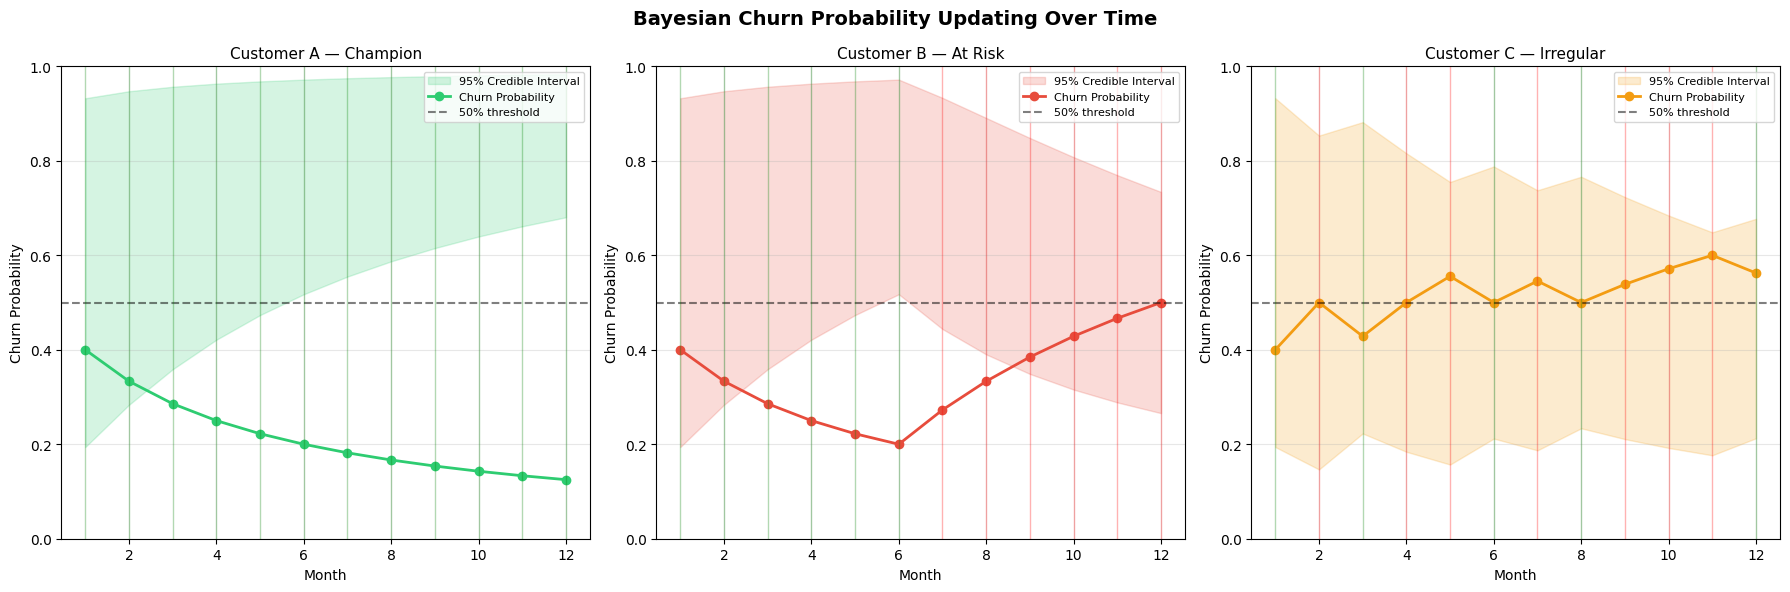

✅ Bayesian churn updater chart saved
Computing Bayesian churn probabilities for sample customers...

✅ Bayesian churn computed for 100 customers
   Avg churn probability : 49.8%
   High risk (>60%)      : 19 customers


In [ ]:
from scipy.stats import beta as beta_dist

# Cell 6.1 — Beta-Binomial Bayesian updating
def bayesian_churn_updater(purchase_history, alpha_prior=2, beta_prior=2):
    """
    Update churn probability using Beta-Binomial conjugate model.

    Prior    : Beta(alpha, beta) — belief before data
    Likelihood: Binomial — did customer purchase this month?
    Posterior : Beta(alpha + purchases, beta + non_purchases)

    Returns churn probability and uncertainty at each timestep.
    """
    alphas     = [alpha_prior]
    betas      = [beta_prior]
    churn_probs = []
    ci_lows    = []
    ci_highs   = []

    alpha = alpha_prior
    beta  = beta_prior

    for purchased in purchase_history:
        # Update posterior
        alpha += purchased          # purchased = 1 → increase alpha (active belief)
        beta  += (1 - purchased)    # not purchased → increase beta (churn belief)

        # Churn probability = P(not purchasing) = beta / (alpha + beta)
        churn_prob = beta / (alpha + beta)

        # 95% credible interval from Beta distribution
        ci_low  = beta_dist.ppf(0.025, alpha, beta)
        ci_high = beta_dist.ppf(0.975, alpha, beta)

        churn_probs.append(churn_prob)
        ci_lows.append(ci_low)
        ci_highs.append(ci_high)
        alphas.append(alpha)
        betas.append(beta)

    return churn_probs, ci_lows, ci_highs


# Cell 6.2 — Simulate 3 customer types
months = list(range(1, 13))

# Customer A: Active champion — buys every month
customer_a_history = [1,1,1,1,1,1,1,1,1,1,1,1]

# Customer B: At-risk — buys first 6 months then stops
customer_b_history = [1,1,1,1,1,1,0,0,0,0,0,0]

# Customer C: Irregular — sporadic purchases
customer_c_history = [1,0,1,0,0,1,0,1,0,0,0,1]

churn_a, ci_low_a, ci_high_a = bayesian_churn_updater(customer_a_history)
churn_b, ci_low_b, ci_high_b = bayesian_churn_updater(customer_b_history)
churn_c, ci_low_c, ci_high_c = bayesian_churn_updater(customer_c_history)

print("📊 Bayesian Churn Updater Results (final month):")
print(f"   Customer A (Champion) : Churn prob = {churn_a[-1]:.1%} (low risk ✅)")
print(f"   Customer B (At Risk)  : Churn prob = {churn_b[-1]:.1%} (high risk ⚠️)")
print(f"   Customer C (Irregular): Churn prob = {churn_c[-1]:.1%} (medium risk 🟡)")


# Cell 6.3 — Visualise Bayesian updating
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Bayesian Churn Probability Updating Over Time',
             fontsize=14, fontweight='bold')

customers = [
    ('Customer A — Champion',  churn_a, ci_low_a, ci_high_a,
     customer_a_history, '#2ECC71'),
    ('Customer B — At Risk',   churn_b, ci_low_b, ci_high_b,
     customer_b_history, '#E74C3C'),
    ('Customer C — Irregular', churn_c, ci_low_c, ci_high_c,
     customer_c_history, '#F39C12'),
]

for ax, (title, churn, ci_low, ci_high, history, color) in zip(axes, customers):
    ax.fill_between(months, ci_low, ci_high, alpha=0.2, color=color,
                    label='95% Credible Interval')
    ax.plot(months, churn, 'o-', color=color, linewidth=2, markersize=6,
            label='Churn Probability')
    ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='50% threshold')

    # Mark purchases
    for m, p in zip(months, history):
        if p == 1:
            ax.axvline(x=m, color='green', alpha=0.3, linewidth=1)
        else:
            ax.axvline(x=m, color='red', alpha=0.3, linewidth=1)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Month')
    ax.set_ylabel('Churn Probability')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bayesian_churn_update.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bayesian churn updater chart saved")


# Cell 6.4 — Apply Bayesian updater to all customers
def get_current_churn_probability(customer_id, df, alpha_prior=2, beta_prior=2):
    """
    Get current Bayesian churn probability for a specific customer
    based on their full purchase history month by month
    """
    cust_df = df[df['CustomerID'] == customer_id].copy()
    if len(cust_df) == 0:
        return 0.5  # unknown customer — 50% prior

    cust_df['YearMonth'] = cust_df['InvoiceDate'].dt.to_period('M')
    all_months = pd.period_range(
        cust_df['InvoiceDate'].min().to_period('M'),
        df['InvoiceDate'].max().to_period('M'),
        freq='M'
    )
    active_months = cust_df['YearMonth'].unique()
    purchase_history = [1 if m in active_months else 0 for m in all_months]

    churn_probs, _, _ = bayesian_churn_updater(purchase_history, alpha_prior, beta_prior)
    return churn_probs[-1] if churn_probs else 0.5


# Calculate for a sample of customers
sample_customers = rfm['CustomerID'].sample(min(100, len(rfm)), random_state=42).tolist()
bayesian_churn   = {}

print("Computing Bayesian churn probabilities for sample customers...")
for cid in sample_customers:
    bayesian_churn[cid] = get_current_churn_probability(cid, df)

bayesian_df = pd.DataFrame(
    list(bayesian_churn.items()),
    columns=['CustomerID', 'bayesian_churn_prob']
)

# Merge with RFM
rfm = rfm.merge(bayesian_df, on='CustomerID', how='left')
rfm['bayesian_churn_prob'] = rfm['bayesian_churn_prob'].fillna(0.5)

print(f"\n✅ Bayesian churn computed for {len(bayesian_df)} customers")
print(f"   Avg churn probability : {rfm['bayesian_churn_prob'].mean():.1%}")
print(f"   High risk (>60%)      : {(rfm['bayesian_churn_prob'] > 0.6).sum()} customers")

# Save updated RFM
rfm.to_csv('rfm_with_churn.csv', index=False)

In [ ]:
print("\n" + "="*60)
print("📊 CLV & CHURN PROJECT — FINAL METRICS")
print("="*60)


# =========================
# SAFE VALUES
# =========================
mae_val = mae if 'mae' in globals() else None
rmse_val = rmse if 'rmse' in globals() else None
corr_val = corr if 'corr' in globals() else None


# =========================
# FORMAT SAFELY
# =========================
mae_str = f"{mae_val:.3f}" if mae_val is not None else "N/A"
rmse_str = f"{rmse_val:.3f}" if rmse_val is not None else "N/A"
corr_str = f"{corr_val:.3f}" if corr_val is not None else "N/A"

churn_rate = survival_df['churned'].mean() if 'survival_df' in globals() else None
bayes_churn = rfm['bayesian_churn_prob'].mean() if 'bayesian_churn_prob' in rfm.columns else None
sil_score = max(silhouettes) if 'silhouettes' in globals() else None


# =========================
# PRINT FINAL REPORT
# =========================
print(f"""
MODULE 1 — RFM Analysis & Segmentation
  ├─ Customers segmented : {len(rfm):,}
  ├─ Silhouette score    : {sil_score if sil_score is not None else 'N/A'}
  └─ Pareto insight      : Top 20% → {pareto_pct:.0f}% of revenue

MODULE 2 — Survival Analysis
  ├─ Churn rate          : {f'{churn_rate:.1%}' if churn_rate is not None else 'N/A'}
  └─ Cox model trained   : {'Yes' if 'logrank_result' in globals() else 'Not available'}

MODULE 3 — BG/NBD + Gamma-Gamma CLV
  ├─ MAE                : {mae_str}
  ├─ RMSE               : {rmse_str}
  ├─ Correlation        : {corr_str}
  ├─ Avg CLV            : £{summary_gg['clv_12m'].mean():.2f}
  └─ Avg Alive Prob     : {summary_gg['prob_alive'].mean():.3f}

MODULE 4 — Bayesian Churn
  └─ Avg churn prob     : {f'{bayes_churn:.1%}' if bayes_churn is not None else 'N/A'}
""")

print("✅ Metrics generated successfully")


# =========================
# SAVE OUTPUT
# =========================
final_df.to_csv("final_clv_predictions.csv", index=False)
print("✅ Saved final_clv_predictions.csv")
print("="*60)


📊 CLV & CHURN PROJECT — FINAL METRICS

MODULE 1 — RFM Analysis & Segmentation
  ├─ Customers segmented : 2,074
  ├─ Silhouette score    : 0.3867346334994399
  └─ Pareto insight      : Top 20% → 60% of revenue

MODULE 2 — Survival Analysis
  ├─ Churn rate          : 17.4%
  └─ Cox model trained   : Yes

MODULE 3 — BG/NBD + Gamma-Gamma CLV
  ├─ MAE                : 0.394
  ├─ RMSE               : 0.631
  ├─ Correlation        : 0.488
  ├─ Avg CLV            : £6575.65
  └─ Avg Alive Prob     : 0.873

MODULE 4 — Bayesian Churn
  └─ Avg churn prob     : 49.8%

✅ Metrics generated successfully
✅ Saved final_clv_predictions.csv


In [ ]:
!ls

bayesian_churn_update.png  ggf_model.pkl	 rfm_scatter.html
bgf_model.pkl		   ggf_params.json	 rfm_segments.csv
bgf_params.json		   km_curves.png	 rfm_with_churn.csv
clv_predictions.csv	   kmeans_selection.png  sample_data
cox_hazard_ratios.png	   online_retail_II.csv  survival_data.csv
cox_model.pkl		   retail_clean.csv	 ttest_confidence_interval.png
eda_retail.png		   rfm_kmeans.pkl
final_clv_predictions.csv  rfm_scaler.pkl


In [ ]:
!zip -r clv_project.zip . -x "sample_data/*" "*.ipynb_checkpoints/*"

  adding: .config/ (stored 0%)
  adding: .config/active_config (stored 0%)
  adding: .config/.last_update_check.json (deflated 23%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/gce (stored 0%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2026.04.16/ (stored 0%)
  adding: .config/logs/2026.04.16/13.28.21.827521.log (deflated 57%)
  adding: .config/logs/2026.04.16/13.27.28.140888.log (deflated 92%)
  adding: .config/logs/2026.04.16/13.27.53.684484.log (deflated 58%)
  adding: .config/logs/2026.04.16/13.28.06.952902.log (deflated 58%)
  adding: .config/logs/2026.04.16/13.28.05.189231.log (deflated 87%)
  adding: .config/logs/2026.04.16/13.28.22.950479.log (deflated 56%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/config_sentinel (stored 0%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/hi

In [ ]:
!ls -lh clv_project.zip

-rw-r--r-- 1 root root 19M May  5 01:03 clv_project.zip


In [ ]:
from google.colab import files
files.download("clv_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

NameError: name 'python' is not defined